# IntentGate: intent classification with abstention

Classify supported English requests, but defer when the model score is too low. We compare word TF-IDF logistic regression, word + character TF-IDF logistic regression, and calibrated linear SVM. The aim is to measure the tradeoff between useful automatic routing and unsupported requests being accepted by mistake. No downstream action is executed.

## 1. Data and experimental contract

[CLINC150](https://github.com/clinc/oos-eval) is a crowdsourced, English, single-intent benchmark from [Larson et al. (2019)](https://aclanthology.org/D19-1131/), licensed [CC BY 3.0](https://creativecommons.org/licenses/by/3.0/). It is not a production ticket stream. Its full version contains 150 supported intents and separate out-of-scope (OOS) examples.

Training fits features and classifiers. Validation selects both the model and rejection threshold. Test results are reported only after these decisions are frozen. OOS training examples are deliberately unused: OOS is detected using the maximum supported-class score, not learned as a single catch-all intent.

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd()
if not (ROOT / "intent_gate").exists():
    ROOT = ROOT.parent
assert (ROOT / "intent_gate").is_dir()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
import pandas as pd
from IPython.display import display, Image
from intent_gate.data import load_data, audit
from intent_gate.train import run
from intent_gate.inference import Router

## 2. Data quality before modeling

Inspect split sizes, class balance, input lengths, duplicate rows and cross-split text overlaps. The source contains a few normalized duplicates between official splits. We retain the official splits for comparability, disclose the overlaps, and report a train-overlap-excluded test accuracy as a sensitivity check. We do not edit training data based on test labels.

In [2]:
data = load_data()
quality = audit(data)
display(pd.DataFrame(quality["splits"]).T)
display(pd.Series({k:v for k,v in quality["cross_split_normalized_overlap"].items() if v}, name="shared normalized texts"))
print("Conflicting normalized texts:", quality["conflicting_normalized_texts"])
print(json.loads((ROOT / "outputs/provenance.json").read_text()))

,rows,classes,class_min,class_max,exact_duplicate_rows,normalized_duplicate_rows,empty_texts,word_count_mean
oos_val,100.0,1.0,100.0,100.0,0.0,0.0,0.0,7.160000
val,3000.0,150.0,20.0,20.0,0.0,0.0,0.0,8.319333
train,15000.0,150.0,100.0,100.0,0.0,0.0,0.0,8.339200
oos_test,1000.0,1.0,1000.0,1000.0,0.0,0.0,0.0,8.746000
test,4500.0,150.0,30.0,30.0,0.0,0.0,0.0,8.191111
oos_train,100.0,1.0,100.0,100.0,0.0,0.0,0.0,7.060000


val:train     3
train:test    2
Name: shared normalized texts, dtype: int64

Conflicting normalized texts: 4
{'repository': 'https://github.com/clinc/oos-eval', 'commit': '828f8093932c8fe6ca7936c3d2e52903b1c523de', 'data_url': 'https://raw.githubusercontent.com/clinc/oos-eval/828f8093932c8fe6ca7936c3d2e52903b1c523de/data/data_full.json', 'license_url': 'https://raw.githubusercontent.com/clinc/oos-eval/828f8093932c8fe6ca7936c3d2e52903b1c523de/LICENSE', 'license': 'CC BY 3.0', 'sha256': '36923c3705a59e08fe9c3883d8bc2dd966ef93e22cb78ac41171782a698d56e0'}


In [3]:
display(pd.DataFrame(data["train"][:8], columns=["text", "intent"]))
lengths = pd.DataFrame({"words": [len(t.split()) for t,_ in data["train"]]})
display(lengths.describe())

,text,intent
0,what expression would i use to say i love you ...,translate
1,can you tell me how to say 'i do not speak muc...,translate
2,"what is the equivalent of, 'life is good' in f...",translate
3,"tell me how to say, 'it is a beautiful morning...",translate
4,"if i were mongolian, how would i say that i am...",translate
5,how do i say 'hotel' in finnish,translate
6,"i need you to translate the sentence, 'we will...",translate
7,please tell me how to ask for a taxi in french,translate


,words
count,15000.000000
mean,8.339200
std,3.191868
min,1.000000
25%,6.000000
50%,8.000000
75%,10.000000
max,28.000000


## 3. Baselines and preprocessing

**Word logistic regression** is the simple lexical baseline: unigram and bigram TF-IDF with sublinear term frequencies. **Word + character logistic regression** adds character 3–5-grams to share evidence across word variants. **Calibrated SVM** uses a linear margin classifier with sigmoid calibration in three training-only folds. The entire feature pipeline lives inside calibration folds to avoid vocabulary/IDF leakage into those folds.

Sparse vectors avoid dense padding and a GPU dependency. There is no oversampling: supported training classes are balanced. TF-IDF handles normalization; there is no need to standardize each sparse feature. These are CPU NLP models, not LLMs or neural embeddings. A transformer comparison is future work, not an implemented feature.

## 4. Selection policy and metrics

For each model, select a threshold that maximizes the fraction of correctly routed validation requests subject to at most 5% empirical false acceptance on the 100 OOS validation examples. Ties prefer fewer accepted mistakes, then a stricter threshold. Select the model by validation correctly routed fraction, with in-scope accuracy as tie-breaker.

Report intent accuracy and macro-F1 before rejection; OOS AUROC; in-scope coverage; accepted in-scope accuracy; OOS false-acceptance rate; and mixed accepted-request accuracy including OOS mistakes. A 5% validation constraint is not a production guarantee. Maximum class probability is only a decision score; it is not a guaranteed probability of correctness.

In [4]:
# Full reproducible experiment: downloads if absent, trains all models, locks
# validation policies, evaluates test, saves artifacts and figures.
results = run()

Training word_lr


Training word_char_lr


Training calibrated_svm


{
  "selected_model": "word_char_lr",
  "results": {
    "word_lr": {
      "fit_seconds": 20.995509499975014,
      "policy": {
        "threshold": 0.6680662683209527,
        "oos_false_accept_rate": 0.05,
        "correct_route_rate": 0.6916666666666667,
        "in_scope_coverage": 0.701
      },
      "validation": {
        "intent_accuracy": 0.9053333333333333,
        "intent_macro_f1": 0.9050957020248448,
        "oos_auroc": 0.9095816666666667,
        "in_scope_coverage": 0.701,
        "selective_accuracy": 0.9866856871136471,
        "correct_route_rate": 0.6916666666666667,
        "oos_false_accept_rate": 0.05,
        "mixed_coverage": 0.68,
        "mixed_selective_accuracy": 0.9843453510436433
      },
      "test": {
        "intent_accuracy": 0.9102222222222223,
        "intent_macro_f1": 0.9095325189887788,
        "oos_auroc": 0.9243028888888888,
        "in_scope_coverage": 0.7177777777777777,
        "selective_accuracy": 0.9820433436532507,
        "correct_ro

## 5. Results after freezing the policy

The model is not picked by the following test table. `selection.json` is written before test reporting. Training durations and batch inference timings are measured locally, not service latency promises.

Validation-selected model: word_char_lr


,intent_accuracy,intent_macro_f1,oos_auroc,in_scope_coverage,selective_accuracy,oos_false_accept_rate,mixed_selective_accuracy,nonoverlap_intent_accuracy
word_lr,0.9102,0.9095,0.9243,0.7178,0.9820,0.049,0.9674,0.9104
word_char_lr,0.9236,0.9227,0.9497,0.7609,0.9871,0.040,0.9758,0.9237
calibrated_svm,0.9093,0.9084,0.9185,0.5878,0.9924,0.040,0.9777,0.9095


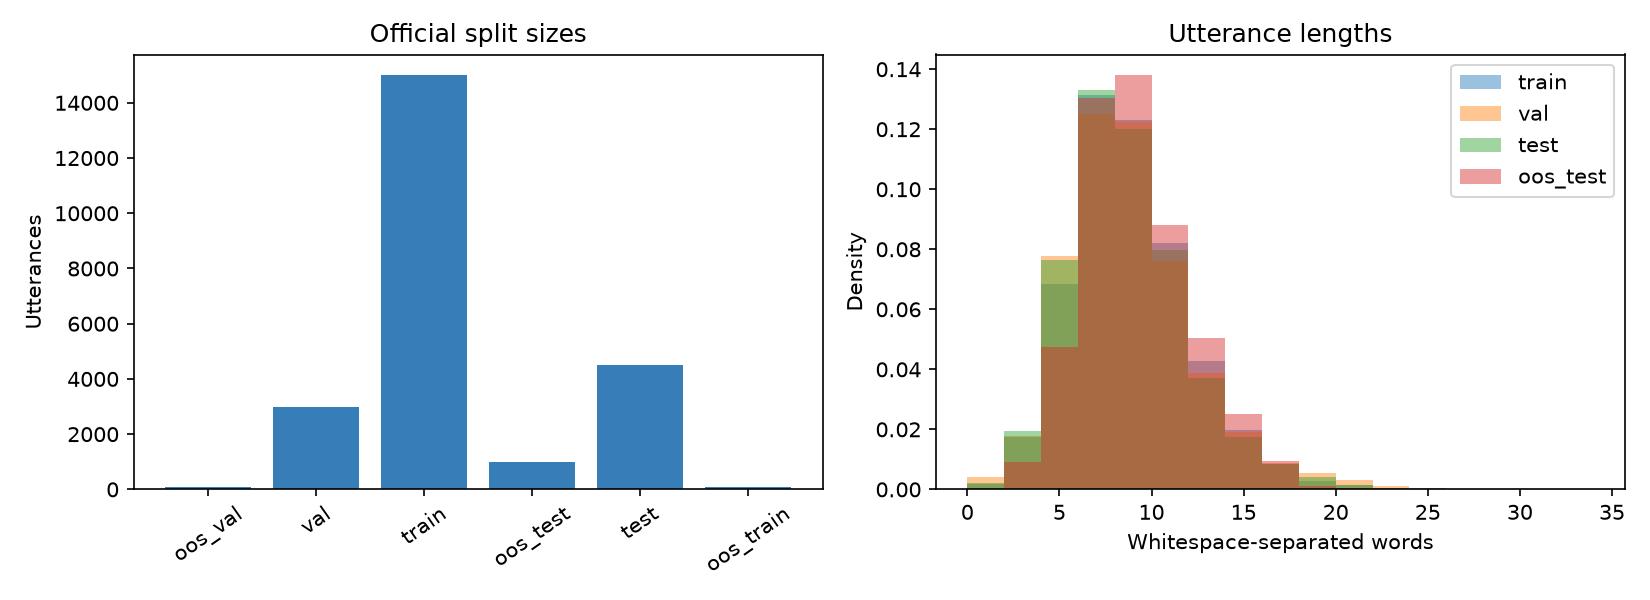

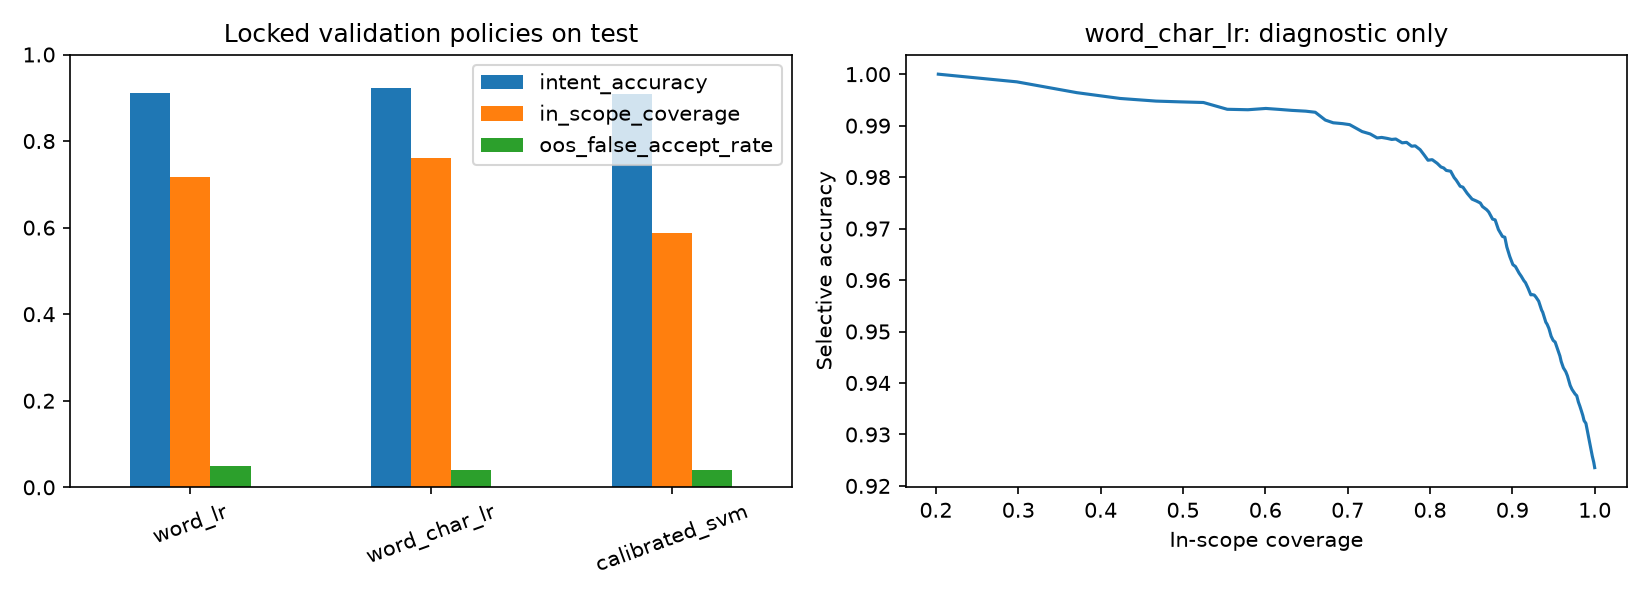

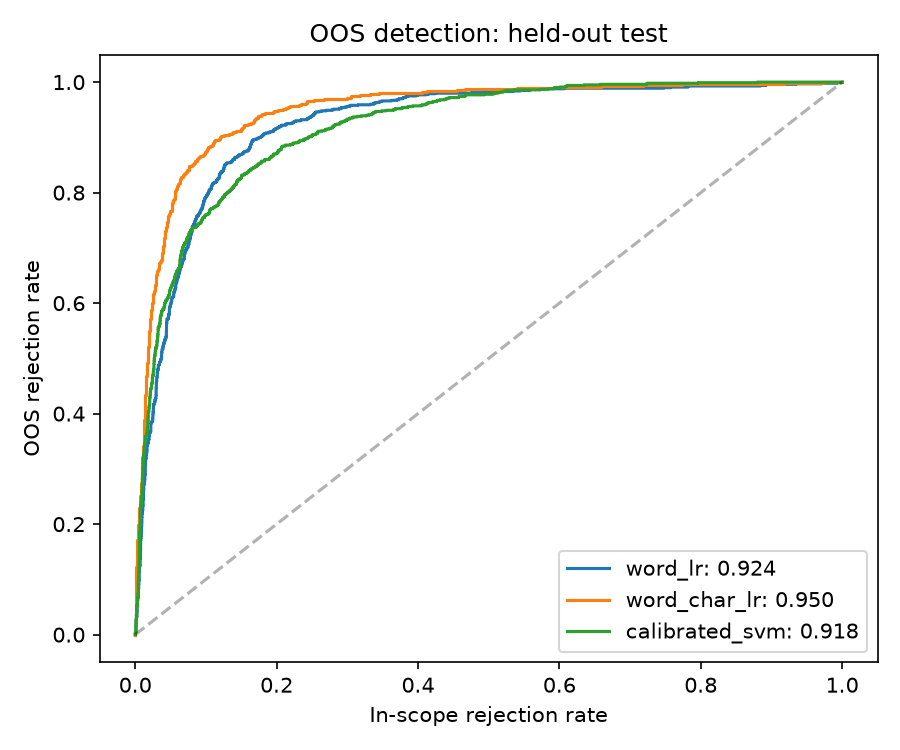

In [5]:
report = json.loads((ROOT / "outputs/metrics.json").read_text())
print("Validation-selected model:", report["selected_model"])
columns = ["intent_accuracy", "intent_macro_f1", "oos_auroc", "in_scope_coverage", "selective_accuracy", "oos_false_accept_rate", "mixed_selective_accuracy", "nonoverlap_intent_accuracy"]
table = pd.DataFrame({name:r["test"] for name,r in report["models"].items()}).T
display(table[columns].round(4))
display(Image(filename=str(ROOT / "outputs/figures/eda.png")))
display(Image(filename=str(ROOT / "outputs/figures/tradeoffs.png")))
display(Image(filename=str(ROOT / "outputs/figures/oos_roc.png")))

## 6. Error analysis and diagnostic curves

Inspect confident mistakes, including unsupported requests accepted as supported intents. The saved coverage curve sweeps thresholds on test for diagnosis only: it must not be used to quietly choose a new deployment threshold. Supported-intent selective accuracy excludes OOS examples; mixed selective accuracy counts them as mistakes. This distinction prevents a flattering but incomplete success claim.

In [6]:
display(pd.read_csv(ROOT / "outputs/high_confidence_errors.csv").head(10))
display(pd.read_csv(ROOT / "outputs/confusion_pairs.csv").head(10))
selected = report["models"][report["selected_model"]]["test"]
accepted = round(selected["in_scope_coverage"] * len(data["test"]))
correct = round(selected["selective_accuracy"] * accepted)
false_accepts = round(selected["oos_false_accept_rate"] * len(data["oos_test"]))
print(f"Supported accepted: {accepted}; correct: {correct}; accepted mistakes: {accepted-correct}")
print("Unsupported accepted:", false_accepts, "/", len(data["oos_test"]))

,model,split,text,true_label,predicted_label,confidence,accepted
0,word_char_lr,oos_test,ignore call,oos,make_call,0.998910,True
1,word_char_lr,oos_test,read text,oos,text,0.998654,True
2,word_char_lr,oos_test,give me the weather forecast for today,oos,weather,0.996770,True
3,word_char_lr,oos_test,deny incoming phone call,oos,make_call,0.993004,True
4,word_char_lr,oos_test,read my friend's text message,oos,text,0.988236,True
5,word_char_lr,oos_test,look up the conversion rate for the euro to do...,oos,exchange_rate,0.987102,True
6,word_char_lr,test,that checks out,yes,order_checks,0.985687,True
7,word_char_lr,test,have i added my doctor's appointment to my cal...,calendar,calendar_update,0.982710,True
8,word_char_lr,oos_test,how long should an essay be,oos,cook_time,0.982323,True
9,word_char_lr,test,how much have i spent on my debit card this month,transactions,spending_history,0.978340,True


,true_label,predicted_label,count
0,calendar,calendar_update,8
1,redeem_rewards,rewards_balance,7
2,improve_credit_score,credit_score,6
3,food_last,expiration_date,5
4,pto_request,pto_request_status,5
5,ingredients_list,recipe,5
6,todo_list,todo_list_update,4
7,shopping_list,shopping_list_update,4
8,transactions,spending_history,4
9,shopping_list,todo_list,4


Supported accepted: 3424; correct: 3380; accepted mistakes: 44
Unsupported accepted: 40 / 1000


## 7. Local inference

The artifact packages the fitted feature pipeline, estimator, model name and threshold. Only load artifacts from a trusted training run: joblib deserialization can execute code. The application returns a suggested intent or abstention; it does not authenticate users, create support tickets or execute financial actions.

In [7]:
router = Router()
for text in ["what is my account balance", "write a poem about a dragon on the moon"]:
    print(text)
    display(router.route(text))

what is my account balance


{'decision': 'route',
 'intent': 'balance',
 'confidence': 0.990287246036463,
 'threshold': 0.7473129252085283,
 'model': 'word_char_lr',
 'candidates': [{'intent': 'balance', 'score': 0.990287246036463},
  {'intent': 'freeze_account', 'score': 0.003539975851671538},
  {'intent': 'account_blocked', 'score': 0.0019133951892122034}]}

write a poem about a dragon on the moon


{'decision': 'abstain',
 'intent': None,
 'confidence': 0.19494757700085633,
 'threshold': 0.7473129252085283,
 'model': 'word_char_lr',
 'candidates': [{'intent': 'fun_fact', 'score': 0.19494757700085633},
  {'intent': 'maybe', 'score': 0.03402235705889568},
  {'intent': 'restaurant_reviews', 'score': 0.031094469834018555}]}

## 8. Interpretation and limitations

Use the validation-selected model for this benchmark, but validate again on the intended domain before deployment. CLINC150 is single-intent English, not multilingual or conversational context. Short lexical models can miss paraphrases and be overconfident on shared keywords. Validation OOS coverage is small, and future unsupported requests may differ substantially. Exact duplicates are disclosed, but near-duplicate leakage is not exhaustively measured.

The next experiments would compare pretrained sentence embeddings and a fine-tuned encoder, then measure cost, latency and OOS detection at the same validation policy. Do not claim those improvements without running them. Deployment proposals—authorization, review queues, privacy-safe monitoring and rollback—are documented separately in `docs/operating-design.md`.

## ML-practice checklist

- Real published dataset and license attribution: **applied**.
- EDA, class balance, missing inputs and duplicate audit: **applied**.
- Official held-out splits and validation-only selection: **applied**, with source-overlap caveat.
- Baseline and two alternatives: **applied**.
- Train-only feature fitting and fold-local calibration: **applied**.
- Oversampling and numerical feature standardization: **not needed** for this balanced sparse-text task.
- GPU training / LLM calls: **not used**.
- Selective prediction, OOS metrics and confident-error analysis: **applied**.
- Real production traffic, load tests and authorization integrations: **not implemented**.
- Notebook rerun and automated tests: run the documented commands; results must be verified, not inferred from this checklist.